<a href="https://colab.research.google.com/github/ruforavishnu/Project_Machine_Learning/blob/master/Project20_Unsupervised_Learning_Market_Basket_analysis_using_association_rule_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mlxtend

### Load dataset from kaggle

In [4]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Groceries_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "heeraldedhia/groceries-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipython-input-280418972.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 257k/257k [00:00<00:00, 81.7MB/s]

Extracting zip of Groceries_dataset.csv...
First 5 records:    Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


**Group Items Into Transactions**

In [5]:
basket = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index()



transactions = basket['itemDescription'].tolist()


print('Total transactions: ', len(transactions))
print(transactions[:5])


Total transactions:  14963
[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'], ['whole milk', 'pastry', 'salty snack'], ['canned beer', 'misc. beverages'], ['sausage', 'hygiene articles'], ['soda', 'pickled vegetables']]


In [7]:
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd


te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)


df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
df_encoded.head()



,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(df_encoded, min_support=0.002,  use_colnames=True)
frequent_itemsets.sort_values('support',  ascending=False).head(10)

,support,itemsets
123,0.157923,(whole milk)
78,0.122101,(other vegetables)
93,0.110005,(rolls/buns)
104,0.097106,(soda)
124,0.085879,(yogurt)
94,0.069572,(root vegetables)
116,0.067767,(tropical fruit)
7,0.060683,(bottled water)
99,0.060349,(sausage)
24,0.053131,(citrus fruit)


In [16]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric='lift',  min_threshold=1)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
12,(curd),(sausage),0.002941,0.087302,1.446615
13,(sausage),(curd),0.002941,0.048726,1.446615
4,(brown bread),(canned beer),0.002406,0.063943,1.362937
5,(canned beer),(brown bread),0.002406,0.051282,1.362937
21,(sausage),(frozen vegetables),0.002072,0.034330,1.225966
20,(frozen vegetables),(sausage),0.002072,0.073986,1.225966
2,(bottled beer),(sausage),0.003342,0.073746,1.222000
3,(sausage),(bottled beer),0.003342,0.055371,1.222000
15,(frankfurter),(other vegetables),0.005146,0.136283,1.116150
14,(other vegetables),(frankfurter),0.005146,0.042146,1.116150


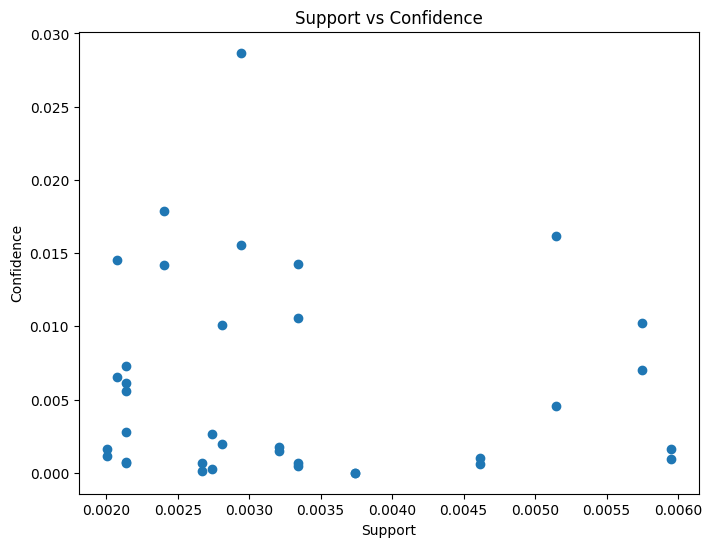

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(rules['support'] , rules['certainty'])
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence')
plt.show()

In [20]:
top_rules = rules.sort_values('lift', ascending=False).head(10)

top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


,antecedents,consequents,support,confidence,lift
12,(curd),(sausage),0.002941,0.087302,1.446615
13,(sausage),(curd),0.002941,0.048726,1.446615
4,(brown bread),(canned beer),0.002406,0.063943,1.362937
5,(canned beer),(brown bread),0.002406,0.051282,1.362937
21,(sausage),(frozen vegetables),0.002072,0.034330,1.225966
20,(frozen vegetables),(sausage),0.002072,0.073986,1.225966
2,(bottled beer),(sausage),0.003342,0.073746,1.222000
3,(sausage),(bottled beer),0.003342,0.055371,1.222000
15,(frankfurter),(other vegetables),0.005146,0.136283,1.116150
14,(other vegetables),(frankfurter),0.005146,0.042146,1.116150


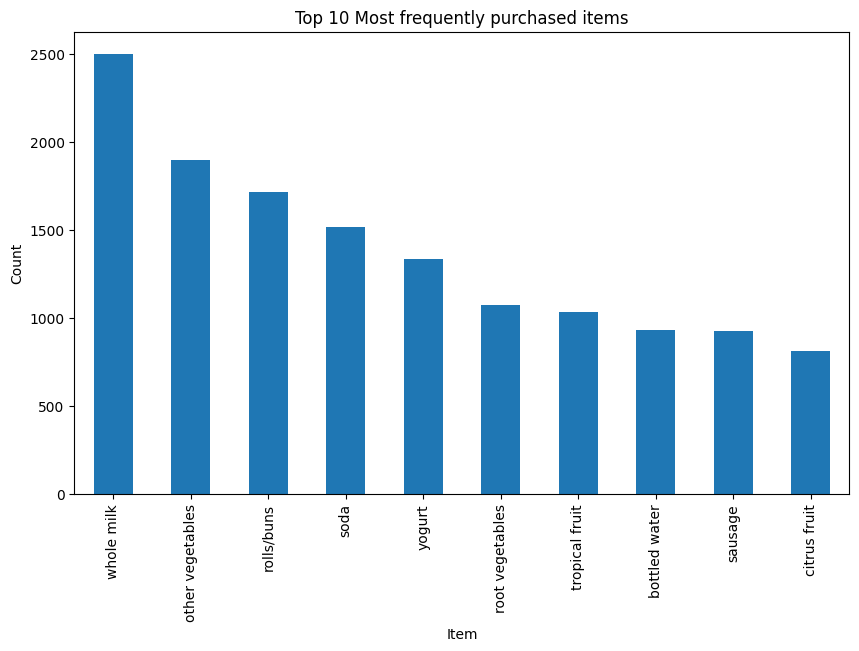

In [22]:
import numpy as np

item_counts = df['itemDescription'].value_counts().head(10)

plt.figure(figsize=(10,6))
item_counts.plot(kind='bar')
plt.title('Top 10 Most frequently purchased items')
plt.xlabel('Item')
plt.ylabel('Count')
plt.show()

In [23]:
simple_rules = rules[

                     (rules['antecedents'].apply(len) == 1)  &
                     (rules['consequents'].apply(len) == 1)
]

top_combos = simple_rules.sort_values('confidence', ascending=False).head(10)

top_combos

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
25,(ham),(whole milk),0.017109,0.157923,0.002740,0.160156,1.014142,1.0,3.821049e-05,1.002659,0.014188,0.015904,0.002652,0.088754
15,(frankfurter),(other vegetables),0.037760,0.122101,0.005146,0.136283,1.116150,1.0,5.355097e-04,1.016420,0.108146,0.033261,0.016154,0.089214
17,(frozen meals),(other vegetables),0.016775,0.122101,0.002139,0.127490,1.044134,1.0,9.039652e-05,1.006176,0.042990,0.015640,0.006138,0.072503
27,(meat),(other vegetables),0.016842,0.122101,0.002139,0.126984,1.039991,1.0,8.223631e-05,1.005593,0.039112,0.015633,0.005562,0.072250
0,(berries),(other vegetables),0.021787,0.122101,0.002673,0.122699,1.004899,1.0,1.303311e-05,1.000682,0.004984,0.018930,0.000681,0.072297
8,(chocolate),(rolls/buns),0.023592,0.110005,0.002807,0.118980,1.081592,1.0,2.117455e-04,1.010188,0.077260,0.021461,0.010085,0.072248
22,(fruit/vegetable juice),(rolls/buns),0.034017,0.110005,0.003743,0.110020,1.000136,1.0,5.091755e-07,1.000017,0.000141,0.026679,0.000017,0.072021
33,(sausage),(soda),0.060349,0.097106,0.005948,0.098560,1.014975,1.0,8.775684e-05,1.001613,0.015702,0.039259,0.001611,0.079906
35,(sausage),(yogurt),0.060349,0.085879,0.005748,0.095238,1.108986,1.0,5.648409e-04,1.010345,0.104587,0.040913,0.010239,0.081082
12,(curd),(sausage),0.033683,0.060349,0.002941,0.087302,1.446615,1.0,9.078510e-04,1.029531,0.319493,0.032282,0.028684,0.068014


In [33]:
print('Top 10 Most important product combinations')

for _, row in top_combos.iloc[::-1].iterrows():
  A = list(row['antecedents'])[0]
  B = list(row['consequents'])[0]


  conf = row['confidence'] * 100
  lift = row['lift']
  supp = row['support'] * 100
  chance = (lift - 1.0) * 100

  print(f'When customers purchase {A.upper()} there is {chance:.3}% chance they will also purchase {B.upper()}')



Top 10 Most important product combinations
When customers purchase CURD there is 44.7% chance they will also purchase SAUSAGE
When customers purchase SAUSAGE there is 10.9% chance they will also purchase YOGURT
When customers purchase SAUSAGE there is 1.5% chance they will also purchase SODA
When customers purchase FRUIT/VEGETABLE JUICE there is 0.0136% chance they will also purchase ROLLS/BUNS
When customers purchase CHOCOLATE there is 8.16% chance they will also purchase ROLLS/BUNS
When customers purchase BERRIES there is 0.49% chance they will also purchase OTHER VEGETABLES
When customers purchase MEAT there is 4.0% chance they will also purchase OTHER VEGETABLES
When customers purchase FROZEN MEALS there is 4.41% chance they will also purchase OTHER VEGETABLES
When customers purchase FRANKFURTER there is 11.6% chance they will also purchase OTHER VEGETABLES
When customers purchase HAM there is 1.41% chance they will also purchase WHOLE MILK


### Beautiful! We have predicted future purchase possibilities of a future customer from our past customer data